In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Paths
RAW = Path("../data/raw")

# Estilo de gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120

print("✅ Librerías cargadas correctamente")

Matplotlib is building the font cache; this may take a moment.


✅ Librerías cargadas correctamente


In [2]:
df_hist = pd.read_csv(RAW / "serie_historica.csv", encoding="utf-8")
df_hist["indice_tiempo"] = pd.to_datetime(df_hist["indice_tiempo"])
df_hist["anio"] = df_hist["indice_tiempo"].dt.year

print(f"Serie histórica: {df_hist.shape[0]} años × {df_hist.shape[1]} columnas")
print(f"Período: {df_hist['anio'].min()} — {df_hist['anio'].max()}")
df_hist.head()


Serie histórica: 110 años × 27 columnas
Período: 1914 — 2023


,indice_tiempo,republica_argentina,capital_federal,buenos_aires,catamarca,cordoba,corrientes,chaco,chubut,entre_rios,...,rio_negro,salta,san_juan,san_luis,santa_cruz,santa_fe,santiago_del_estero,tucuman,tierra_del_fuego,anio
0,1914-01-01,119852,23486,25599,1483,12939,4483,475,453,6124,...,500,3440,2682,1752,111,12835,3400,8388,44,1914
1,1915-01-01,124885,23904,26283,1345,14239,5348,492,446,6692,...,611,3240,2760,1835,136,13957,3358,8081,12,1915
2,1916-01-01,137952,23289,29696,1651,15770,5495,665,611,8626,...,547,3438,2831,2054,155,17078,3598,8405,3,1916
3,1917-01-01,129691,22337,26543,1566,15440,5377,847,368,7732,...,450,3067,2848,2017,95,15092,4393,9865,8,1917
4,1918-01-01,148097,23805,29320,2701,16942,6175,971,409,8294,...,497,4042,4844,2588,109,17032,4311,12873,9,1918


In [7]:

años = [2022, 2023, 2024]
dfs = []

for año in años:
    path = RAW / f"defunciones_{año}.csv"
    for enc in ("utf-8", "latin-1", "iso-8859-1"):
        try:
            df = pd.read_csv(path, encoding=enc, low_memory=False, sep=';')
            df["anio"] = año
            dfs.append(df)
            print(f"✅ {año}: {df.shape[0]:,} filas × {df.shape[1]} columnas | columnas: {list(df.columns)}")
            break
        except UnicodeDecodeError:
            continue

df_def = pd.concat(dfs, ignore_index=True)
print(f"\nDataset combinado: {df_def.shape[0]:,} filas")

✅ 2022: 49,146 filas × 7 columnas | columnas: ['PROVRES', 'SEXO', 'CAUSA', 'MAT', 'GRUPEDAD', 'CUENTA', 'anio']
✅ 2023: 50,188 filas × 7 columnas | columnas: ['PROVRES', 'SEXO', 'CAUSA', 'MAT', 'GRUPEDAD', 'CUENTA', 'anio']
✅ 2024: 54,251 filas × 7 columnas | columnas: ['PROVRES', 'SEXO', 'CAUSA', 'MAT', 'GRUPEDAD', 'CUENTA', 'anio']

Dataset combinado: 153,585 filas


In [8]:
print(df_def["CAUSA"].unique()[:20])


<StringArray>
['G93', 'V58', 'I61', 'P77', 'L08', 'X84', 'J43', 'J45', 'C76', 'G10', 'C50',
 'V49', 'K92', 'E10', 'C62', 'N17', 'E46', 'E88', 'A09', 'W13']
Length: 20, dtype: str


In [9]:
df_def["capitulo"] = df_def["CAUSA"].str[0]


In [10]:
print(df_def["capitulo"].value_counts())

capitulo
C    32295
I    24921
K    12932
J    12293
V     6775
E     6642
G     6601
X     6368
D     6058
R     5887
N     5447
Y     4685
A     4579
W     3528
B     2826
Q     2512
M     2288
L     1881
P     1794
F     1485
U     1216
O      542
H       30
Name: count, dtype: int64


In [12]:
# Nombres legibles para los capítulos más importantes
capitulos = {
    "C": "Tumores (cáncer)",
    "I": "Cardiovasculares",
    "J": "Respiratorias",
    "K": "Digestivas",
    "E": "Endócrinas/Diabetes",
    "G": "Neurológicas",
    "X": "Lesiones autoinfligidas",
    "V": "Accidentes de tránsito",
}

# Top 5 capítulos por total
top5 = (df_def.groupby("capitulo")["CUENTA"]
        .sum()
        .sort_values(ascending=False)
        .head(5)
        .index.tolist())

# Evolución temporal de los top 5
evol = (df_def[df_def["capitulo"].isin(top5)]
        .groupby(["anio", "capitulo"])["CUENTA"]
        .sum()
        .reset_index())

evol["capitulo_nombre"] = evol["capitulo"].map(capitulos).fillna(evol["capitulo"])
print(evol)

    anio capitulo  CUENTA   capitulo_nombre
0   2022        A   17748                 A
1   2022        C   59605  Tumores (cáncer)
2   2022        I   99454  Cardiovasculares
3   2022        J   67717     Respiratorias
4   2022        R   25167                 R
5   2023        A   16300                 A
6   2023        C   59121  Tumores (cáncer)
7   2023        I  110062  Cardiovasculares
8   2023        J   74698     Respiratorias
9   2023        R   27272                 R
10  2024        A   20360                 A
11  2024        C   59702  Tumores (cáncer)
12  2024        I  105130  Cardiovasculares
13  2024        J   77523     Respiratorias
14  2024        R   29162                 R


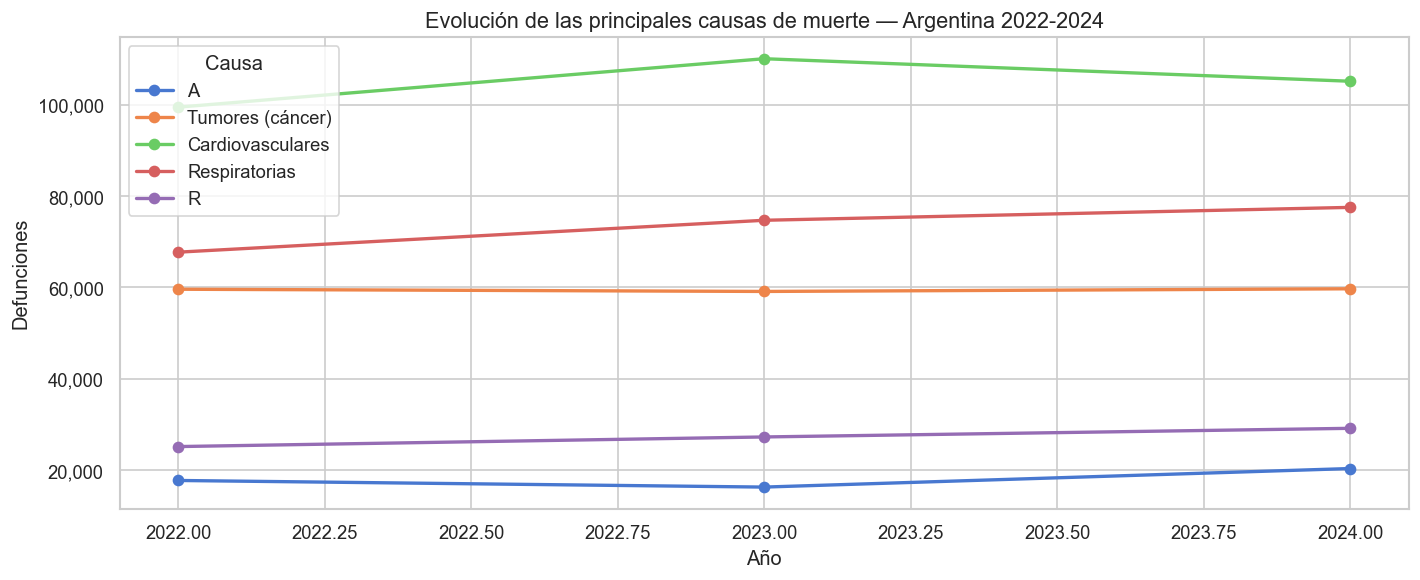

✅ Gráfico guardado


In [13]:
fig, ax = plt.subplots()

for cap in evol["capitulo_nombre"].unique():
    datos = evol[evol["capitulo_nombre"] == cap]
    ax.plot(datos["anio"], datos["CUENTA"], marker="o", label=cap, linewidth=2)

ax.set_title("Evolución de las principales causas de muerte — Argentina 2022-2024", fontsize=13)
ax.set_xlabel("Año")
ax.set_ylabel("Defunciones")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(title="Causa")
plt.tight_layout()
plt.savefig("../data/evolucion_causas.png", dpi=150)
plt.show()
print("✅ Gráfico guardado")

## DATO INTERESANTE OBSERVADO
Las causas mal definidas (R) ocupan el 4to lugar con ~27k-29k muertes anuales y muestran
tendencia creciente. Esto indica subregistro en la certificación de defunciones: los números
reales de causas específicas como cardiovasculares y tumores están probablemente subestimados.

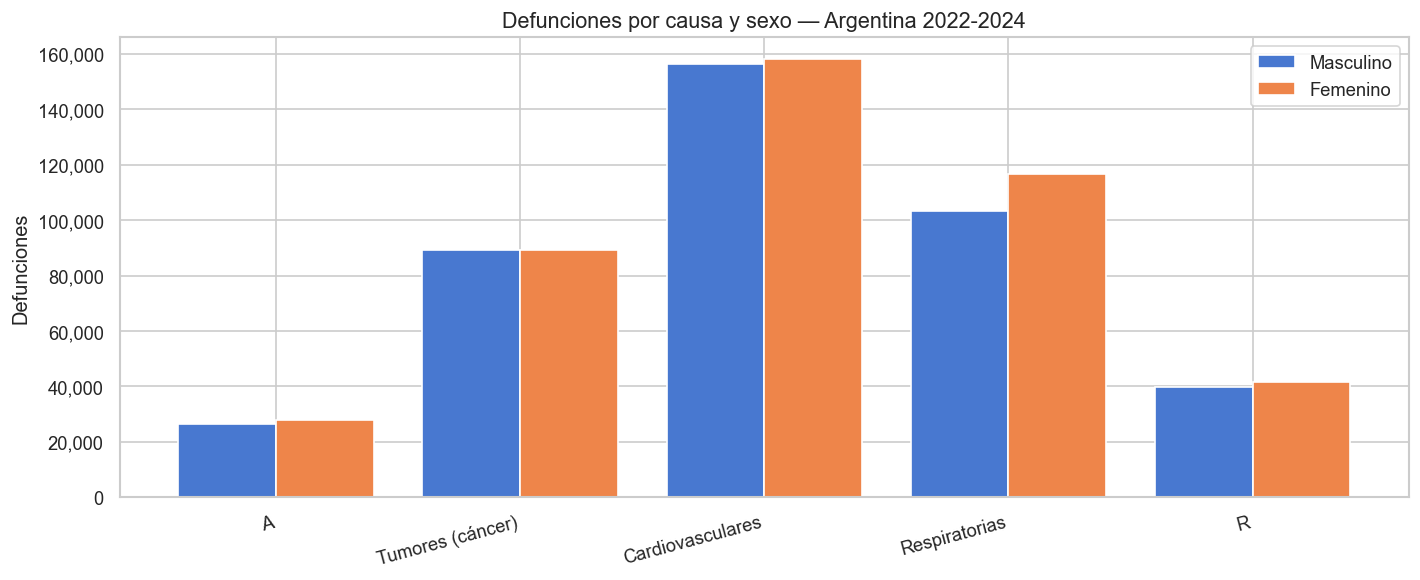

✅ Gráfico guardado


In [14]:
# SEXO: 1=Masculino, 2=Femenino, 3=Indeterminado
sexo_map = {1: "Masculino", 2: "Femenino", 3: "Indeterminado"}
df_def["sexo_nombre"] = df_def["SEXO"].map(sexo_map)

sexo_causa = (df_def[df_def["capitulo"].isin(top5)]
              .groupby(["capitulo", "sexo_nombre"])["CUENTA"]
              .sum()
              .reset_index())

sexo_causa["capitulo_nombre"] = sexo_causa["capitulo"].map(capitulos).fillna(sexo_causa["capitulo"])
sexo_causa = sexo_causa[sexo_causa["sexo_nombre"].isin(["Masculino", "Femenino"])]

fig, ax = plt.subplots()
x = range(len(sexo_causa["capitulo_nombre"].unique()))
causas = sexo_causa["capitulo_nombre"].unique()

for i, sexo in enumerate(["Masculino", "Femenino"]):
    datos = sexo_causa[sexo_causa["sexo_nombre"] == sexo]
    offset = -0.2 if i == 0 else 0.2
    ax.bar([xi + offset for xi in x], datos["CUENTA"], width=0.4, label=sexo)

ax.set_xticks(list(x))
ax.set_xticklabels(causas, rotation=15, ha="right")
ax.set_title("Defunciones por causa y sexo — Argentina 2022-2024", fontsize=13)
ax.set_ylabel("Defunciones")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend()
plt.tight_layout()
plt.savefig("../data/causas_por_sexo.png", dpi=150)
plt.show()
print("✅ Gráfico guardado")

## DATO INTERESANTE OBSERVADO
La principal causa de muerte en Argentina es cardiovascular (I), no oncológica como sugería el conteo de registros. La diferencia se explica porque CUENTA refleja muertes reales mientras que las filas representan combinaciones de provincia/sexo/grupo etario.

In [15]:
print(df_def.groupby("capitulo")["CUENTA"].agg(["sum", "count", "mean"]).sort_values("sum", ascending=False).head(8))


             sum  count       mean
capitulo                          
I         314646  24921  12.625737
J         219938  12293  17.891320
C         178428  32295   5.524942
R          81601   5887  13.861220
A          54408   4579  11.882070
K          47677  12932   3.686746
N          45681   5447   8.386451
E          37585   6642   5.658687


## DATO INTERESANTE OBSERVADO
El cáncer (C) aparece en más combinaciones provincia+sexo+edad que las cardiovasculares (I), pero con menor concentración por grupo. Las cardiovasculares matan más pero en perfiles demográficos más específicos. Esto tiene implicancias para políticas de salud pública: el cáncer requiere intervención amplia, las cardiovasculares pueden focalizarse.

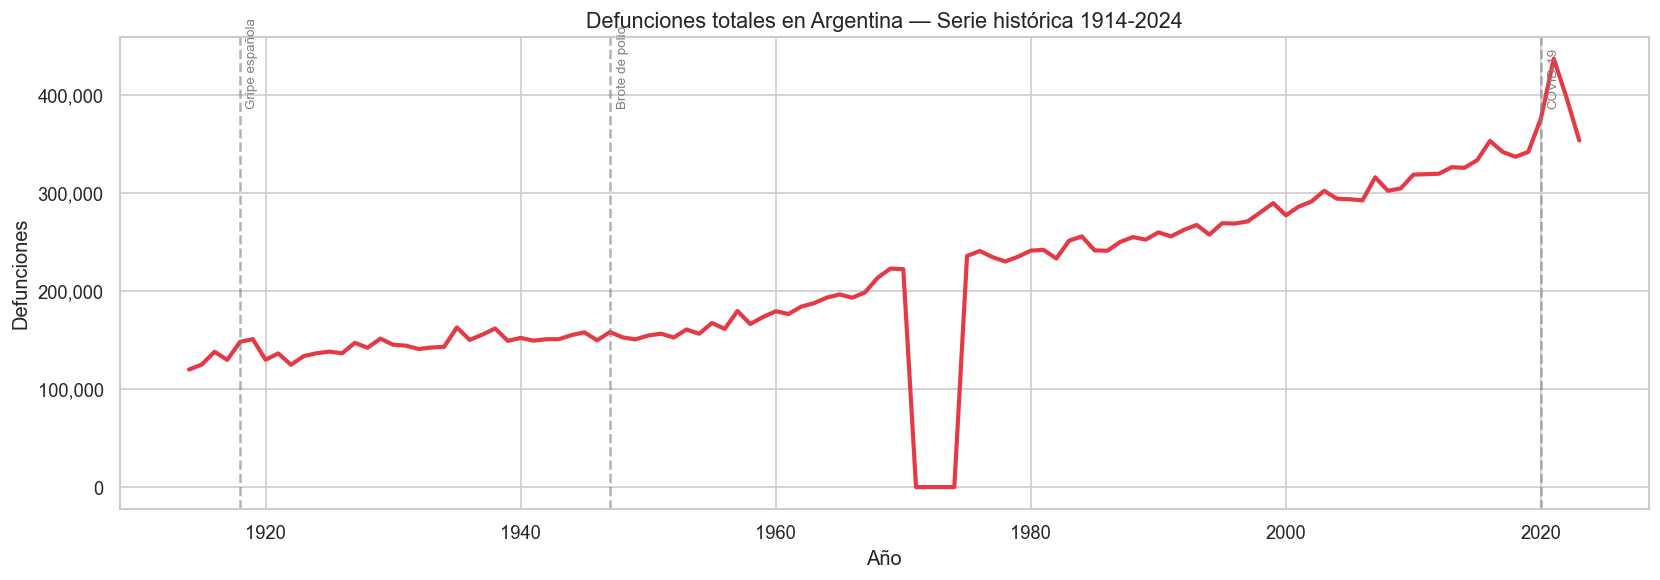

In [16]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_hist["anio"], df_hist["republica_argentina"], 
        color="#e63946", linewidth=2.5, label="Total país")

# Marcar eventos históricos clave
eventos = {
    1918: "Gripe española",
    1947: "Brote de polio",
    2020: "COVID-19",
}
for anio, label in eventos.items():
    ax.axvline(x=anio, color="gray", linestyle="--", alpha=0.6)
    ax.text(anio + 0.5, ax.get_ylim()[1] * 0.85, label, 
            fontsize=8, color="gray", rotation=90)

ax.set_title("Defunciones totales en Argentina — Serie histórica 1914-2024", fontsize=13)
ax.set_xlabel("Año")
ax.set_ylabel("Defunciones")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("../data/serie_historica.png", dpi=150)
plt.show()

In [17]:
print(df_hist[df_hist["republica_argentina"] < 50000][["anio", "republica_argentina"]])

    anio  republica_argentina
57  1971                    0
58  1972                    0
59  1973                    0
60  1974                    0


## DATO INTERESANTE OBSERVADO
Los años 1971-1974 presentan valores en 0 que representan datos incompletos en el dataset original de la DEIS, no una caída real de mortalidad.
Para análisis de tendencias se recomienda excluir este período o imputar valores.

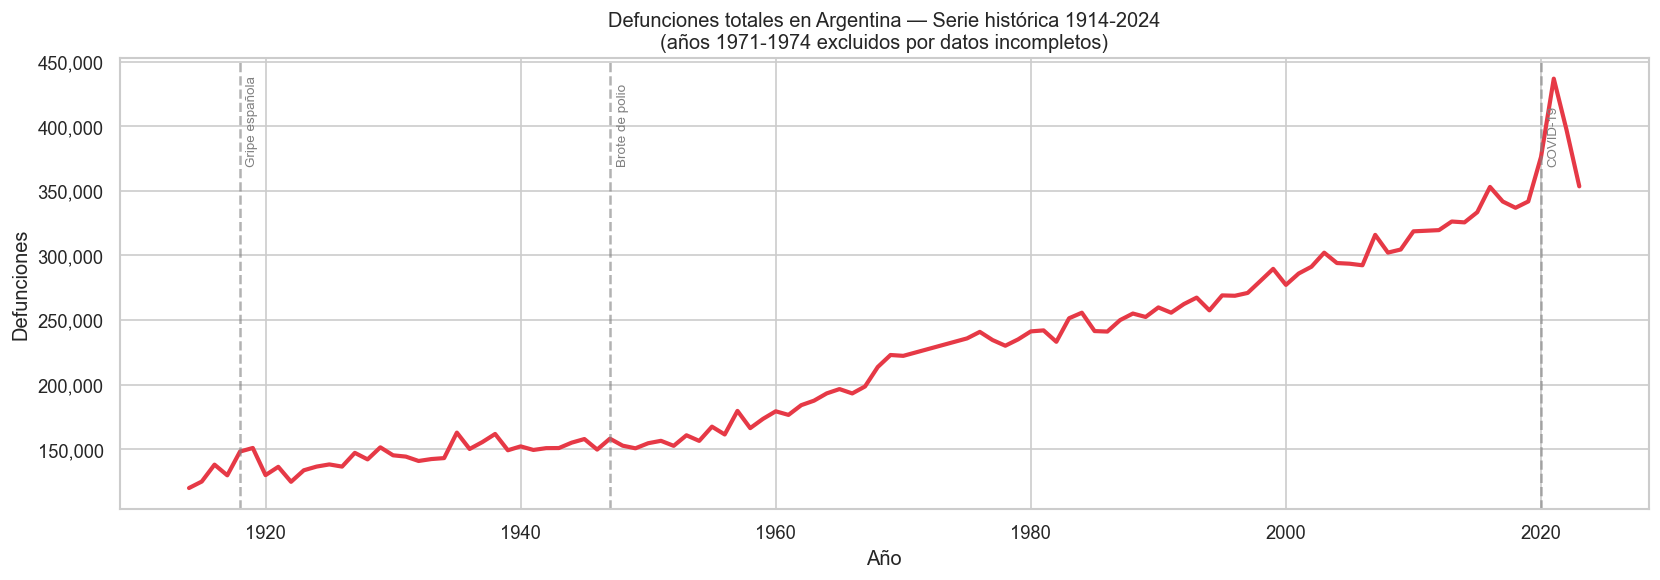

In [18]:
# Filtrar años con datos incompletos
df_hist_clean = df_hist[~df_hist["anio"].isin([1971, 1972, 1973, 1974])]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_hist_clean["anio"], df_hist_clean["republica_argentina"], 
        color="#e63946", linewidth=2.5, label="Total país")

eventos = {
    1918: "Gripe española",
    1947: "Brote de polio",
    2020: "COVID-19",
}
for anio, label in eventos.items():
    ax.axvline(x=anio, color="gray", linestyle="--", alpha=0.6)
    ax.text(anio + 0.5, df_hist_clean["republica_argentina"].max() * 0.85, 
            label, fontsize=8, color="gray", rotation=90)

ax.set_title("Defunciones totales en Argentina — Serie histórica 1914-2024\n(años 1971-1974 excluidos por datos incompletos)", fontsize=12)
ax.set_xlabel("Año")
ax.set_ylabel("Defunciones")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("../data/serie_historica_clean.png", dpi=150)
plt.show()

In [21]:
prov_map_correcto = {
    2: "CABA",
    6: "Buenos Aires",
    10: "Catamarca",
    14: "Córdoba",
    18: "Corrientes",
    22: "Chaco",
    26: "Chubut",
    30: "Entre Ríos",
    34: "Formosa",
    38: "Jujuy",
    42: "La Pampa",
    46: "La Rioja",
    50: "Mendoza",
    54: "Misiones",
    58: "Neuquén",
    62: "Río Negro",
    66: "Salta",
    70: "San Juan",
    74: "San Luis",
    78: "Santa Cruz",
    82: "Santa Fe",
    86: "Sgo. del Estero",
    90: "Tucumán",
    94: "T. del Fuego"
}

df_def["provincia"] = df_def["PROVRES"].map(prov_map_correcto)

# Verificar que no quedaron nulos
print(df_def["provincia"].isnull().sum(), "filas sin mapear")
print(df_def["provincia"].value_counts().head(10))

2571 filas sin mapear
provincia
Buenos Aires    20952
Santa Fe        11662
Córdoba         10666
CABA             9362
Mendoza          8481
Salta            7530
Chaco            7100
Tucumán          6824
Entre Ríos       6627
Corrientes       5832
Name: count, dtype: int64


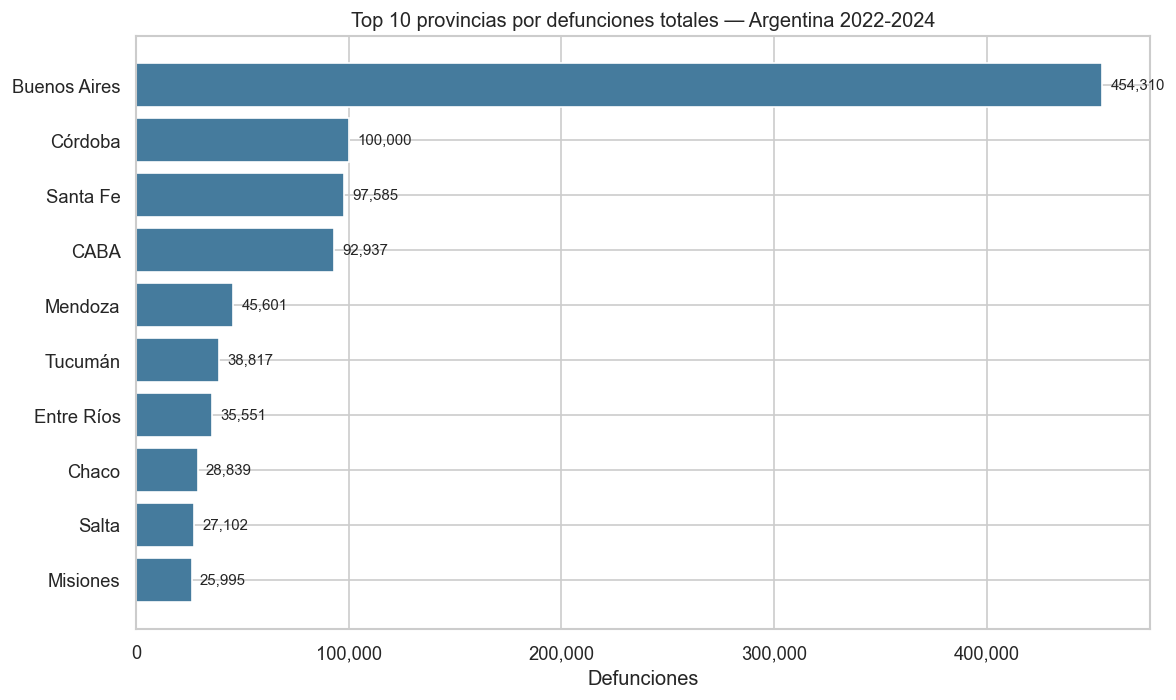

In [22]:
top_prov = (df_def.groupby("provincia")["CUENTA"]
            .sum()
            .sort_values(ascending=True)
            .tail(10))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_prov.index, top_prov.values, color="#457b9d")
ax.bar_label(bars, fmt=lambda x: f"{int(x):,}", padding=5, fontsize=9)
ax.set_title("Top 10 provincias por defunciones totales — Argentina 2022-2024", fontsize=12)
ax.set_xlabel("Defunciones")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("../data/defunciones_por_provincia.png", dpi=150)
plt.show()

## CONCLUSIONES FINALES

1. **La principal causa de muerte en Argentina son las enfermedades cardiovasculares (I)** 
   con más de 314k defunciones en 2022-2024, seguidas de respiratorias y tumores.

2. **El cáncer aparece más distribuido demográficamente** que las cardiovasculares, 
   que se concentran en perfiles específicos de edad y región.

3. **Las causas mal definidas (R) representan ~27k muertes anuales con tendencia creciente**, 
   lo que indica problemas en la certificación de defunciones y subestimación de causas específicas.

4. **La distribución por provincia es proporcional a la población**, validando la 
   consistencia interna del dataset.

5. **El pico de 2020-2021 en la serie histórica es el evento más disruptivo en 50 años**, 
   superando incluso el impacto relativo de la gripe española de 1918.

6. **Los años 1971-1974 presentan datos incompletos** en el registro oficial de la DEIS,
   no una caída real de mortalidad.